In [61]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import joblib


In [24]:
data = pd.read_csv("../datasets/archive/xAPI-Edu-Data.csv")

In [25]:
data.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [26]:
data.shape

(480, 17)

In [27]:
data.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='str')

In [28]:
data.info

<bound method DataFrame.info of     gender NationalITy PlaceofBirth       StageID GradeID SectionID  \
0        M          KW       KuwaIT    lowerlevel    G-04         A   
1        M          KW       KuwaIT    lowerlevel    G-04         A   
2        M          KW       KuwaIT    lowerlevel    G-04         A   
3        M          KW       KuwaIT    lowerlevel    G-04         A   
4        M          KW       KuwaIT    lowerlevel    G-04         A   
..     ...         ...          ...           ...     ...       ...   
475      F      Jordan       Jordan  MiddleSchool    G-08         A   
476      F      Jordan       Jordan  MiddleSchool    G-08         A   
477      F      Jordan       Jordan  MiddleSchool    G-08         A   
478      F      Jordan       Jordan  MiddleSchool    G-08         A   
479      F      Jordan       Jordan  MiddleSchool    G-08         A   

         Topic Semester Relation  raisedhands  VisITedResources  \
0           IT        F   Father           15   

In [29]:
data.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [30]:
data.isnull().sum()

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

In [31]:
data.nunique()

gender                       2
NationalITy                 14
PlaceofBirth                14
StageID                      3
GradeID                     10
SectionID                    3
Topic                       12
Semester                     2
Relation                     2
raisedhands                 82
VisITedResources            89
AnnouncementsView           88
Discussion                  90
ParentAnsweringSurvey        2
ParentschoolSatisfaction     2
StudentAbsenceDays           2
Class                        3
dtype: int64

In [32]:
data['Class'].value_counts()

Class
M    211
H    142
L    127
Name: count, dtype: int64

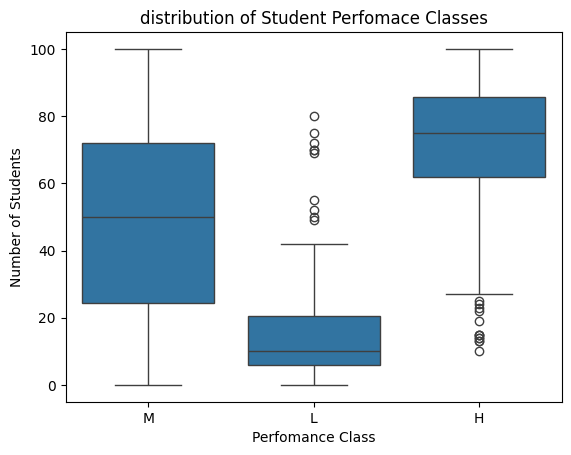

In [33]:
sns.boxplot(x ="Class", y ='raisedhands', data = data)
plt.xlabel("Perfomance Class")
plt.ylabel("Number of Students")
plt.title("distribution of Student Perfomace Classes")
plt.show()

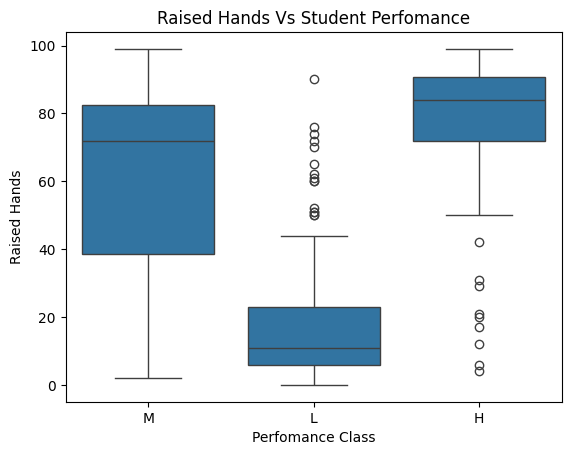

In [34]:
sns.boxplot(x = "Class", y ="VisITedResources", data = data)
plt.xlabel("Perfomance Class")
plt.ylabel("Raised Hands")
plt.title("Raised Hands Vs Student Perfomance")
plt.show()

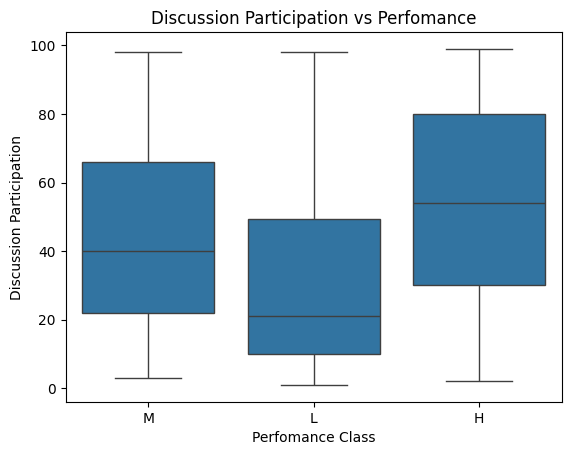

In [35]:
sns.boxplot(x = "Class", y = "Discussion", data = data)
plt.xlabel("Perfomance Class")
plt.ylabel("Discussion Participation")
plt.title("Discussion Participation vs Perfomance")
plt.show()


In [36]:
data.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='str')

In [37]:
data["engagement_score"] = (
    data["raisedhands"] + 
    data["VisITedResources"] + 
    data["AnnouncementsView"] + 
    data["Discussion"]
    
    )

In [38]:
data.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,engagement_score
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,53
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,68
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,47
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,95
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,152


<Axes: >

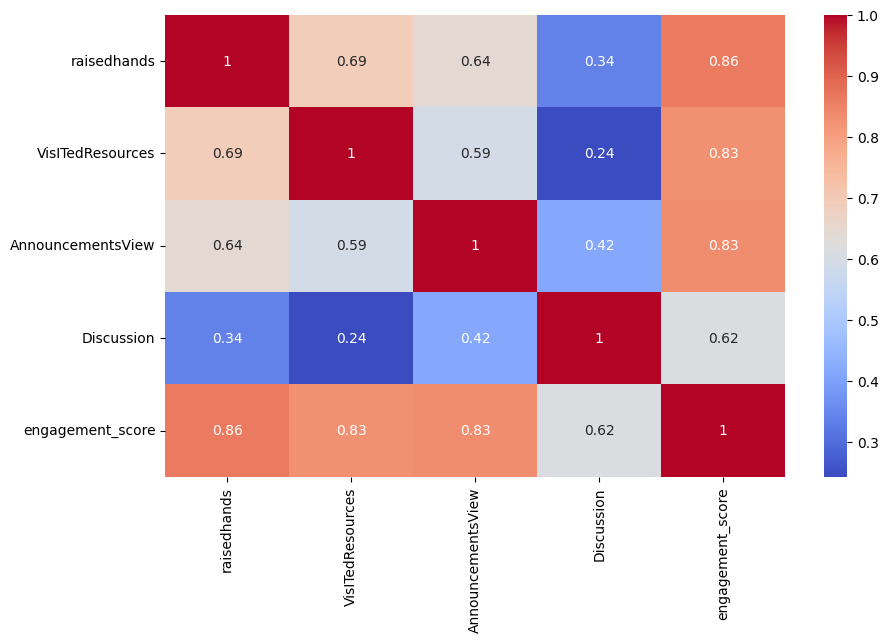

In [39]:
plt.figure(figsize = (10,6))

sns.heatmap(
    data[
            [
            "raisedhands",
            "VisITedResources",
            "AnnouncementsView",
            "Discussion",
            "engagement_score"
            ]
        ].corr(),
        annot = True,
        cmap = "coolwarm"
)

In [40]:
features = data[
    [
        'raisedhands',
        'VisITedResources',
        'AnnouncementsView',
        'Discussion'
        ]
    ]

In [41]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

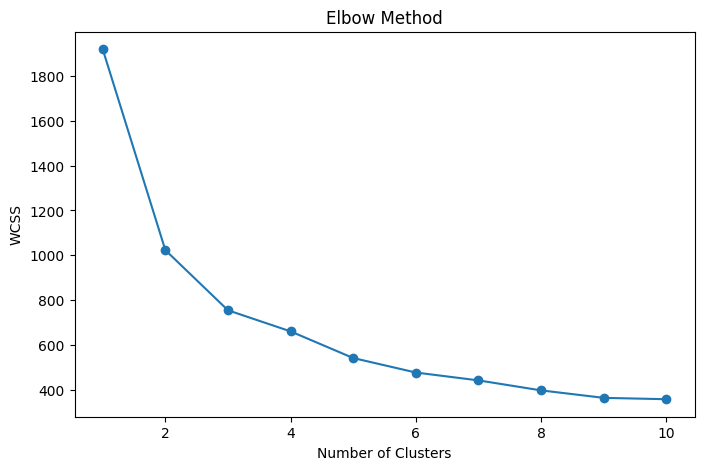

In [42]:
wcss = []
for i in range(1,11):
    Kmeans = KMeans(
        n_clusters = i,
        init = 'k-means++',
        random_state = 42
        )
    
    Kmeans.fit(scaled_features)
    
    wcss.append(Kmeans.inertia_)
    
plt.figure(figsize = (8,5))

plt.plot(range(1, 11), wcss, marker ='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()
    

In [45]:
kmeans = KMeans(n_clusters=3, random_state=42)

data['Cluster'] = kmeans.fit_predict(scaled_features)

In [48]:
cluster_summary = data.groupby('Cluster')[[
    'raisedhands',
    'VisITedResources',
    'AnnouncementsView',
    'Discussion',
    'engagement_score'
    ]].mean()

In [47]:
data[['engagement_score','Cluster']].head()

,engagement_score,Cluster
0,53,2
1,68,2
2,47,2
3,95,2
4,152,2


In [49]:
print(cluster_summary)

         raisedhands  VisITedResources  AnnouncementsView  Discussion  \
Cluster                                                                 
0          58.529032         78.096774          38.522581   26.774194   
1          73.444444         78.718519          65.903704   74.251852   
2          18.236842         18.794737          17.542105   34.747368   

         engagement_score  
Cluster                    
0              201.922581  
1              292.318519  
2               89.321053  


In [52]:
cluster_names = {
    0: "Low Engagement",
    1: "Medium Engagement",
    3: "High Engagement"
}

data['Engagement_Level'] = data['Cluster'].map(cluster_names)

data[["Cluster", 'Engagement_Level']].head()

,Cluster,Engagement_Level
0,2,NaN
1,2,NaN
2,2,NaN
3,2,NaN
4,2,NaN


In [53]:
data['Cluster'].unique()

array([2, 1, 0], dtype=int32)

In [54]:
data.groupby('Cluster')['engagement_score'].mean()

Cluster
0    201.922581
1    292.318519
2     89.321053
Name: engagement_score, dtype: float64

In [ ]:
data['Cluster'] = data['Cluster'].astype(int)

cluster_names = {
    0: "Low Engagement",
    1: "Medium Engagement",
    2: "High Engagement"
}

data['Engagement_Level'] = data['Cluster'].map(cluster_names)

data[['Cluster', 'Engagement_Level']].head()

,Cluster,Engagement_Level
0,2,High Engagement
1,2,High Engagement
2,2,High Engagement
3,2,High Engagement
4,2,High Engagement


In [58]:
data[['Cluster', 'Engagement_Level']].tail()

,Cluster,Engagement_Level
475,2,High Engagement
476,0,Low Engagement
477,0,Low Engagement
478,2,High Engagement
479,2,High Engagement


Text(0, 0.5, 'number of Students')

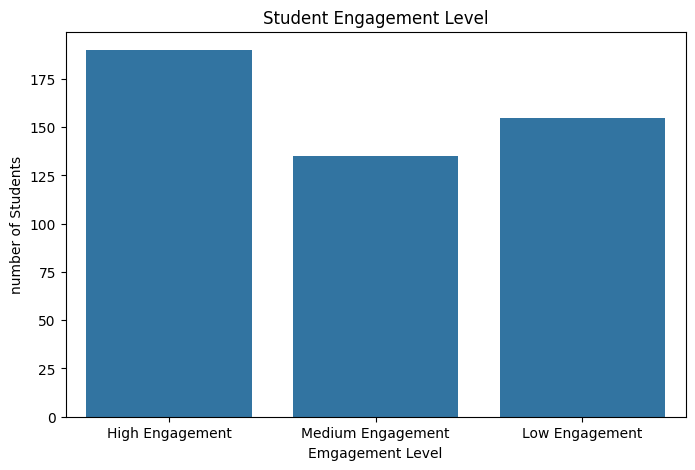

In [ ]:
plt.figure(figsize =(8, 5))

sns.countplot(
    x = 'Engagement_Level',
    data = data
)

plt.title("Student Engagement Level")
plt.xlabel("Emgagement Level")
plt.ylabel("number of Students")

plt.show()

In [65]:
joblib.dump(kmeans, "../ml_models/student_cluster_model.pkl")
joblib.dump(scaler, "../ml_models/scaler.pkl")

print("Model Saved Successfully)")

Model Saved Successfully)
